# 01 - Seismic Data Preparation & Exploratory Data Analysis (EDA) for binary classification : Earthquake & Noise

## Overview
Continuous seismic recording stations monitor ground motion around the clock across three orthogonal spatial components:
- **Z (Vertical)**: Ground motion in the upward/downward direction.
- **N (North-South)**: Horizontal motion along the north-south axis.
- **E (East-West)**: Horizontal motion along the east-west axis.

The **STEAD (Stanford Earthquake Dataset)** is a global catalog containing millions of annotated three-component seismogram.

### Objectives in this Notebook
1. **Extract and Filter**: Isolate local earthquake traces ($M > 2.5, d \le 21\text{ km}$) and ambient noise traces using the project's [`Data_PreProcessing`](../Data_PreProcessing) module.
2. **Window & Align**: Standardize each trace to a fixed temporal window of $2000$ samples ($20\text{ s}$ at $100\text{ Hz}$), centering earthquake windows on the P-wave arrival.
3. **Standardize (Z-score)**: Apply sequence-wise, channel-wise Z-score normalization.
4. **Exploratory Data Analysis (EDA)**:
   - Inspect multi-component waveforms for both earthquakes and noise.
   - Perform Frequency Domain Analysis via Fast Fourier Transform (FFT) and Power Spectral Density (PSD).
   - Verify normalization statistics across train, validation, and test splits.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

# Ensure project root is in sys.path to import Config, Data_PreProcessing, etc.
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from Config.dataset_config import extractedSTEAD

print(f"Project root: {ROOT_DIR}")
print(f"Target dataset specification: {extractedSTEAD}")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Project root: D:\Desktop\Intership IT\SSL&SeismicData
Target dataset specification: {'name': 'extractedSTEAD', 'n_class': 2, 'n_channel': 3, 'n_length': 2000}


## 1. Inspecting the Extraction Pipeline Logic

The project handles extraction via [`Data_PreProcessing/STEAD_Data_Extraction_V2.py`](../Data_PreProcessing/STEAD_Data_Extraction_V2.py).

### Key Filtering & Preprocessing Criteria:
- **Sampling Rate**: $100\text{ Hz}$ (Nyquist frequency = $50\text{ Hz}$).
- **Component Order**: `ZNE` (Vertical, North-South, East-West).
- **Local Earthquakes Filter**:
  - `trace_category == 'earthquake_local'`
  - `source_magnitude > 2.5`
  - `source_distance_km <= 21`
- **Noise Filter**:
  - `trace_category == 'noise'`
- **Windowing**:
  - Length: $N = 2000$ timesteps.
  - Earthquake: Windowed around `trace_p_arrival_sample` using `sbg.WindowAroundSample`.
  - Noise: Random $2000$-sample window using `sbg.RandomWindow`.
- **Normalization**:
  - Channel-wise Z-score normalization per sequence.

In [5]:
# Check data directory contents and array shapes
data_dir = ROOT_DIR / "data"
train_x_path = data_dir / "train" / "x.npy"
train_y_path = data_dir / "train" / "y.npy"
val_x_path   = data_dir / "validation" / "x.npy"
val_y_path   = data_dir / "validation" / "y.npy"
test_x_path  = data_dir / "test" / "x.npy"
test_y_path  = data_dir / "test" / "y.npy"

if not train_x_path.exists():
    print("Preprocessed files not found. Running data extraction")
    from Data_PreProcessing.STEAD_Data_Extraction_V2 import dataBuilder
    dataBuilder()
else:
    print("Preprocessed dataset already exists on disk.")

# Load preprocessed arrays into memory
X_train, y_train = np.load(train_x_path), np.load(train_y_path)
X_val, y_val     = np.load(val_x_path), np.load(val_y_path)
X_test, y_test   = np.load(test_x_path), np.load(test_y_path)

print("Dataset Dimensions & Partitions")
print(f"Training set: X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation set: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test set: X = {X_test.shape}, y = {y_test.shape}")
print(f"Channels: {X_train.shape[1]} ")
print(f"Timesteps: {X_train.shape[2]} ")

Preprocessed dataset already exists on disk.
Dataset Dimensions & Partitions
Training set: X = (4800, 3, 2000), y = (4800,)
Validation set: X = (600, 3, 2000), y = (600,)
Test set: X = (600, 3, 2000), y = (600,)
Channels: 3 
Timesteps: 2000 


## 2. Dataset Partitioning & Class Balance

Let's confirm the class distribution across all splits to ensure perfectly stratified representation between class `0` (Ambient Noise) and class `1` (Earthquake).

,Split,Noise (0),Earthquake (1),Total,Earthquake Ratio
0,Train (80%),2386,2414,4800,50.3%
1,Val (10%),307,293,600,48.8%
2,Test (10%),307,293,600,48.8%


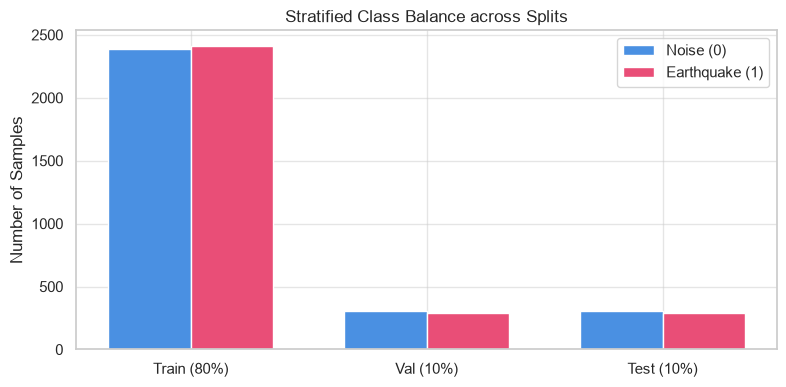

In [6]:
split_data = []
for split_name, y_arr in [("Train (80%)", y_train), ("Val (10%)", y_val), ("Test (10%)", y_test)]:
    n_noise = int(np.sum(y_arr == 0))
    n_eq    = int(np.sum(y_arr == 1))
    split_data.append({
        "Split": split_name,
        "Noise (0)": n_noise,
        "Earthquake (1)": n_eq,
        "Total": len(y_arr),
        "Earthquake Ratio": f"{n_eq / len(y_arr):.1%}"
    })

df_splits = pd.DataFrame(split_data)
display(df_splits)

# Plot split distribution
fig, ax = plt.subplots(figsize=(8, 4))
bar_w = 0.35
x_idx = np.arange(len(df_splits))
ax.bar(x_idx - bar_w/2, df_splits['Noise (0)'], bar_w, label='Noise (0)', color='#4A90E2')
ax.bar(x_idx + bar_w/2, df_splits['Earthquake (1)'], bar_w, label='Earthquake (1)', color='#E94E77')
ax.set_xticks(x_idx)
ax.set_xticklabels(df_splits['Split'])
ax.set_ylabel("Number of Samples")
ax.set_title("Stratified Class Balance across Splits")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Waveform Visualization (Earthquake vs. Noise)

Now let's examine individual seismograms:
- **Earthquake Traces**: Distinct arrival of the **P-wave** , followed by the higher-amplitude **S-wave** , then decaying waves.
- **Noise Traces**: Stationary background vibrations, or random instrument noise without characteristic.

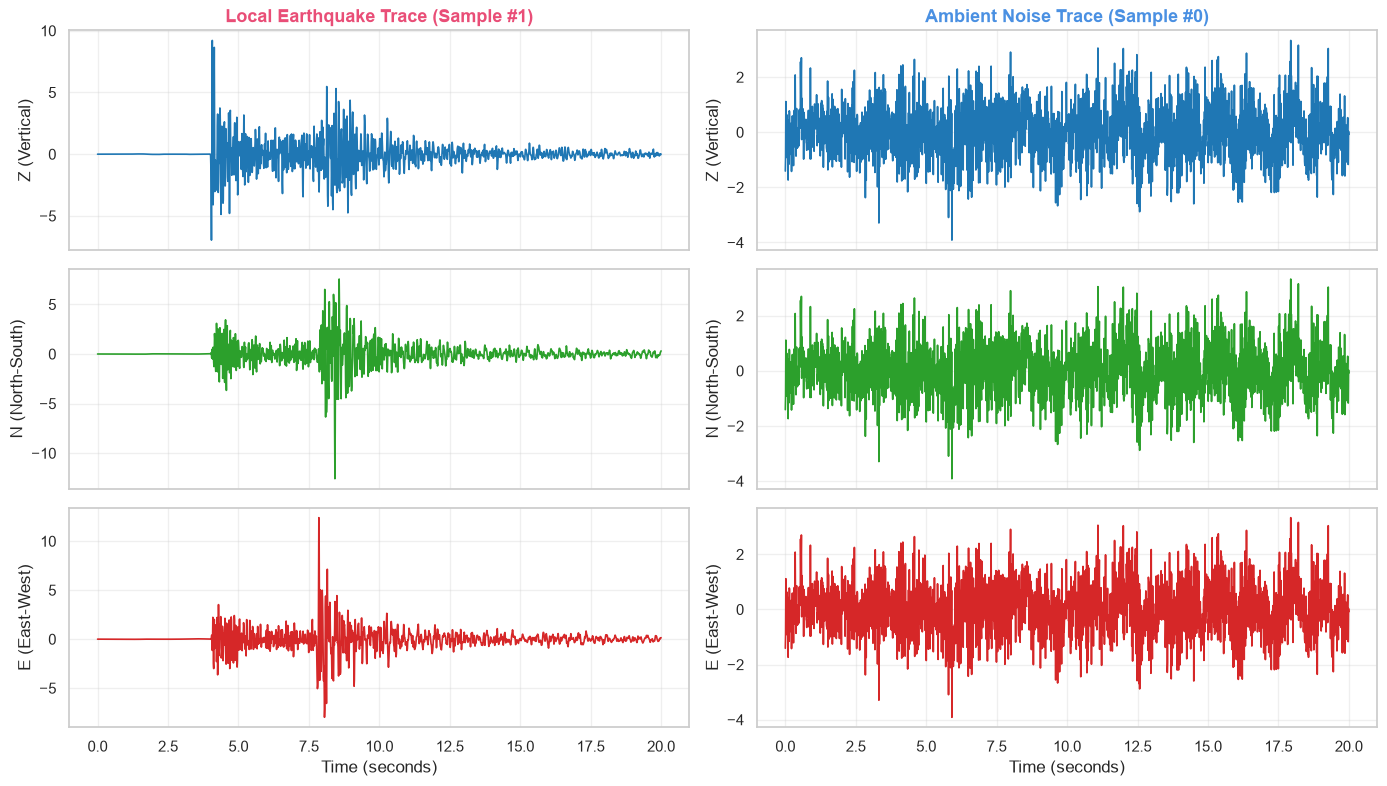

In [7]:
# Find indices of an earthquake and a noise sample
eq_idx = np.where(y_train == 1)[0][0]
noise_idx = np.where(y_train == 0)[0][0]

time_axis = np.linspace(0, 20.0, extractedSTEAD['n_length'])
channel_names = ['Z (Vertical)', 'N (North-South)', 'E (East-West)']
colors = ['#1f77b4', '#2ca02c', '#d62728']

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)

# Plot Earthquake
for c in range(3):
    axes[c, 0].plot(time_axis, X_train[eq_idx, c, :], color=colors[c], lw=1.2)
    axes[c, 0].set_ylabel(channel_names[c])
    axes[c, 0].grid(True, alpha=0.3)
axes[0, 0].set_title(f"Local Earthquake Trace (Sample #{eq_idx})", fontsize=13, fontweight='bold', color='#E94E77')
axes[2, 0].set_xlabel("Time (seconds)")

# Plot Noise
for c in range(3):
    axes[c, 1].plot(time_axis, X_train[noise_idx, c, :], color=colors[c], lw=1.2)
    axes[c, 1].set_ylabel(channel_names[c])
    axes[c, 1].grid(True, alpha=0.3)
axes[0, 1].set_title(f"Ambient Noise Trace (Sample #{noise_idx})", fontsize=13, fontweight='bold', color='#4A90E2')
axes[2, 1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

## 4. Sequence Normalization Verification

Each trace was normalized channel-wise with Z-score standardization:
$$\mu_c = \frac{1}{L} \sum_{t=1}^L X_{c, t} \approx 0, \quad \sigma_c = \sqrt{\frac{1}{L} \sum_{t=1}^L (X_{c, t} - \mu_c)^2} \approx 1$$

Let's confirm the mean and standard deviation across all samples and channels in the training set.

In [10]:
means = np.mean(X_train, axis=2)  # shape: (N, 3)
stds  = np.std(X_train, axis=2)   # shape: (N, 3)

print("Mean across all traces (should be ~0.0):")
for c, name in enumerate(['Z', 'N', 'E']):
    print(f"  Channel {name}: mean = {np.mean(means[:, c]):.6f}, std of means = {np.std(means[:, c]):.6f}")

print("\nStd dev across all traces (should be ~1.0):")
for c, name in enumerate(['Z', 'N', 'E']):
    print(f"  Channel {name}: mean std = {np.mean(stds[:, c]):.6f}, std of stds = {np.std(stds[:, c]):.6f}")


Mean across all traces (should be ~0.0):
  Channel Z: mean = -0.000000, std of means = 0.000000
  Channel N: mean = -0.000000, std of means = 0.000000
  Channel E: mean = 0.000000, std of means = 0.000000

Std dev across all traces (should be ~1.0):
  Channel Z: mean std = 1.000000, std of stds = 0.000000
  Channel N: mean std = 0.999375, std of stds = 0.024992
  Channel E: mean std = 0.999375, std of stds = 0.024992
